## Домашнее задание 3 (10 баллов)

## НИУ ВШЭ, 2024-25 учебный год

Султанбекова Орнелла ИАД-9

## Формат сдачи

Сам ноутбук называйте в формате hw-03-USERNAME.ipynb, где USERNAME — ваши фамилия и имя. Файл надо будет сдать в anytask.

## О задании

В этом домашнем задании вы получите опыт подготовки данных и EDA (Exploratory Data Analysis), приблизившись к реальной работе с данными с помощью уже знакомых вам инструментов: numpy, pandas, matplotlib и seaborn, а также познакомитесь с plotly.

EDA - важный этап работы с данными. Именно в процессе EDA вы можете выяснить особенности датасета, найти зависимости в данных, протестировать гипотезы о взаимосвязях признаков и целевой переменной. В реальности вы сами будете определять, что и как проверять в рамках EDA, однако в данной работе гипотезы будут выдвинуты за вас автором задания. Также и типы графиков, которые вы будете использовать уже предопределены за вас. Выполняя задания по визуализациям, обращайте внимание на референсные картинки, которые были оставлены авторами. Они показывают, какой примерно результат от вас ожидается.

Это задание будет включать в себя построение некоторого количества графиков, потому вот основные правила, в соответствии с которыми графики должны быть оформлены:
1. Любой график всегда имеет название.
2. Оси у графика подписаны (исключение - график делит название оси с соседним).
3. Подписи делаются на одном языке (либо английский, либо русский), но не на их смеси.
4. Если вы выводите несколько графиков, то они размещаются в рамках одного объекта matplotlib.pyplot.figure. Вы не выводите графики последовательно, а смотрите, как их разместить сразу все за раз.
5. Отдельные графики (если графиков на картинке больше 1) также имеют свои названия.
6. Если на графике есть несколько различных объектов, то для их различения используется легенда. Помещайте легенду в место, где она в наименьшей мере мешает восприятию самого графика.
7. Если есть легенда, то она должна иметь название, а также ее содержание должно быть адекватными (пожалейте проверяющих, они не хотят разбирать, а к чему относится зеленая линия, которая на легенде помечена меткой "0").
8. Используйте цветовые гаммы, чтобы объекты на графиках отличались цветом.
9. Текст на визуализации должен быть читаем. Если вы вывели названия категорий в качестве подписей на оси Х, а эти названия наезжают друг на друга, то вам нужно что-то с этим сделать. Нечитаемый или плохо читаемый (очень маленький, невероятно огромный) текст ведет к снижению баллов.

При работе с табличными данными используйте функционал [style](https://pandas.pydata.org/docs/user_guide/style.html#Builtin-Styles), чтобы визуально выделять необходимые элементы.

В этом задании будут оцениваться ваши развернутые комментарии, размышления и выводы (по построенным графикам): не скупитесь на них, но следите, чтобы выводы не были поверхностными и очевидными.

*Тут правило про плагиат, которое вам итак известно - обнуляются все работы, которые подозреваются в некорректных заимствованиях!* Помните, что просто скопировать код из интернета и указать источник - это не ваша самостоятельная работа, а автора кода. Измените хоть что-нибудь в коде.

## О данных

Будем работать с [датасетом физической активности](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones).

В этом датасете собраны данные 30 человек, выполняющих различные действия со смартфоном на поясе. Данные записывались с помощью датчиков (акселерометра и гироскопа) в этом смартфоне. Были зафиксированы: "3-осевое линейное ускорение" (_tAcc-XYZ_) и "3-осевая угловая скорость" (_tGyro-XYZ_).

1. Все сигналы отсортированы по времени, пропущены через фильтр шума.
2. Все наблюдения были разделены на окна по 128 сигналов в каждом, причем окна пересекаются на 50% (грубо говоря, с 1 по 128 сигнал в 1 окно, с 64 до 192 сигнала - во 2 окно и так далее). То есть каждое окно покрывает 2.56 секунды данных (два шага человека при ходьбе, учитывая медленную походку пожилых людей).
3. Линейное ускорение было разделено на две составляющие (с помощью низкочастотного фильтра): ускорение самого тела, а также гравитационная составляющая. Будем называть их ускорением тела и гравитационным ускорением.
4. К получившимся окнам применяли различные функции для получения следующих показателей:
    - max
    - min
    - mad (median)
    - mean
    - std
    - skewness (коэффициент асимметричности распределения признака в окне)
    - etc. (подробнее, на сколько это возможно, указано в [самой статье](https://www.esann.org/sites/default/files/proceedings/legacy/es2013-84.pdf))
5. Величина (magnitude) сигнала также определялась через евклидову норму всех значений из вектора для одного окна.
6. К окнам было применено преобразование Фурье, чтобы получить частоты. Из частот были извелченыте же показатели, плюс новые:
    - bandsEnergy (энергия частотного интервала)
7. Были посчитаны углы между векторами соответствующих окон.
8. Для ускорений были посчитаны производные - рывки, к которым применялись те же функции.

Итог: в датасете каждый признак - это какая-то операция над вектором из 128 чисел, которые соответствуют замерам определенного человека занятого какой-то активностью на протяжении 2.56 секунд.

Как читать названия признаков? Примеры:
- `tBodyAccMag-mean()` - это вектор ускорений тела (без гравитационной составляющей этого ускорения), из которого взяли евклидову норму, а затем усреднили, чтобы получить скаляр
- `fBodyAcc-bandsEnergy()-1,8.2` - это вектор ускорения тела, к которому применили преобразование Фурье, преобразовав его в вектор частот, а затем посчитали на этом векторе энергию данного частотного интервала в определенном диапазоне частот (в данном случае 1 - 8.2)
- `angle(X,gravityMean)` - это угол между осью Х и вектором усредненных значений гравитационного ускорения из соответствующего окна

Вероятно, сначала покажется сложным, но мы разберемся с некоторыми признаками в отдельности и вы сможете понять их смысл, уже исходя из фактических соотношений.

## Предобработка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")

In [ ]:
train.shape

(7352, 563)

В датасете 563 признака, включая целевую переменную. Столько признаков нам не нужно. Мы за вас сделали подвыборку признаков для удобства работы с ними.

In [ ]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [ ]:
train = train[cols_subset]
test = test[cols_subset]

In [ ]:
train.head()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
0,-0.959434,-0.992165,0.977436,-0.934724,-0.993592,-0.841247,0.179941,-0.058627,0.142051,1,STANDING
1,-0.979289,-0.989876,0.984520,-0.943068,-0.998235,-0.844788,0.180289,-0.054317,-0.692541,1,STANDING
2,-0.983703,-0.987868,0.986770,-0.938692,-0.999388,-0.848933,0.180637,-0.049118,-0.727227,1,STANDING
3,-0.986542,-0.991241,0.986821,-0.938692,-0.999807,-0.848649,0.181935,-0.047663,-0.599118,1,STANDING
4,-0.992827,-0.992882,0.987434,-0.942469,-0.999806,-0.847865,0.185151,-0.043892,-0.676997,1,STANDING


### Задание 1 (0.5 балла)

Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [ ]:
# ٩(◕‿◕｡)۶ your code here
nan_train = train.isna().sum()
nan_test = test.isna().sum()
print(nan_train, nan_test, sep='\n\n')

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64


In [ ]:
dup_train = train.duplicated().sum()
dup_test = test.duplicated().sum()
print(dup_train, dup_test, sep='\n')

0
0


Пропусков и дублей нет ни в датасете train, ни в test

### Задание 2 (0.5 балла)

Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.

In [ ]:
# (ノಠ益ಠ)ノ彡 your code here
train.describe()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,-0.543884,-0.727735,0.678505,-0.468604,-0.847963,-0.489547,0.058593,-0.056515,-0.128562,17.413085
std,0.477653,0.315832,0.508656,0.544547,0.233633,0.511807,0.297480,0.279122,0.403686,8.975143
min,-1.000000,-0.999889,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.931208,1.000000
25%,-0.983282,-0.991595,0.804270,-0.936219,-0.999480,-0.812065,-0.017885,-0.143414,-0.486841,8.000000
50%,-0.883371,-0.950268,0.926693,-0.881637,-0.986582,-0.709417,0.182071,0.003181,-0.163271,19.000000
75%,-0.106892,-0.474625,0.965095,-0.017129,-0.764508,-0.509079,0.248353,0.107659,0.155112,26.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.478157,1.000000,1.000000,30.000000


In [ ]:
test.describe()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,-0.559043,-0.735661,0.696878,-0.462063,-0.880361,-0.513923,0.074886,-0.048720,-0.154042,12.986427
std,0.439539,0.282074,0.502873,0.523916,0.160496,0.509205,0.324300,0.241467,0.392203,6.950984
min,-0.998936,-1.000000,-0.756774,-0.952357,-0.999989,-0.984195,-0.913704,-0.949228,-1.000000,2.000000
25%,-0.978433,-0.989078,0.836787,-0.934447,-0.999330,-0.829722,0.022140,-0.098485,-0.497070,9.000000
50%,-0.861830,-0.914698,0.934930,-0.852659,-0.979336,-0.729648,0.181563,-0.010671,-0.202050,12.000000
75%,-0.149596,-0.486423,0.970871,-0.009965,-0.799113,-0.545939,0.260252,0.092373,0.140254,18.000000
max,0.479547,0.117606,0.996148,0.786436,0.048730,0.833180,1.000000,0.973113,0.960367,24.000000


В основном данные уже масштабированы ( или нормализованны) так как находятся в диапозоне [-1, 1]. Исключения составляют два столбца: 1) `subject` - номер испытуемого; 2) `Activity` - вид активности (категориальный признак). Также можно наблюдать смещение, так как медиана и среднее не совпадают, а имеют небольшой разброс.

### Задание 3 (0.5 балла)

Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [ ]:
# ‿( ́ ̵ _-`)‿ your code here
unique_active_count_train = train['Activity'].value_counts()
unique_active_count_test = test['Activity'].value_counts()
print("Train\n\n", unique_active_count_train)
print("\nTest\n\n", unique_active_count_test)

train_l = unique_active_count_train.max()
train_s = unique_active_count_train.min()
train_diff_percent = round((1 - (train_s / train_l)) * 100)
print(f"\nTrain dataset: крупная категория - {train_l}, маленькая - {train_s}. Разница: {train_diff_percent}%")

test_l = unique_active_count_test.max()
test_s = unique_active_count_test.min()
test_diff_percent = round((1 - (test_s / test_l)) * 100)
print(f"\nTrain dataset: крупная категория - {test_l}, маленькая - {test_s}. Разница: {test_diff_percent}%")

if train_diff_percent <= 30 and test_diff_percent <= 30:
    print("Данные сбалансированы в обоих датасетах.")
elif train_diff_percent <= 30:
    print("Данные сбалансированы только в Train.")
elif test_diff_percent <= 30:
    print("Данные сбалансированы только в Test.")
else:
  print("Данные не сбалансированы.")

Train

 Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Test

 Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

Train dataset: крупная категория - 1407, маленькая - 986. Разница: 30%

Train dataset: крупная категория - 537, маленькая - 420. Разница: 22%
Данные сбалансированы в обоих датасетах.


### Задание 4 (0.5 балла)

Посчитайте корреляции всех признаков (включая таргет) со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [ ]:
# ( ͡° ͜ʖ ͡°) your code here
correlation_matrix = pd.get_dummies(train, columns=['Activity'])
correlation_matrix.corr()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity_LAYING,Activity_SITTING,Activity_STANDING,Activity_WALKING,Activity_WALKING_DOWNSTAIRS,Activity_WALKING_UPSTAIRS
tBodyAccMag-mean(),1.000000,0.899080,0.369962,0.959827,0.697832,-0.370849,0.495561,0.426283,0.379796,-0.073652,-0.396643,-0.396389,-0.414460,0.358825,0.561344,0.405434
tBodyGyroJerk-mad()-X,0.899080,1.000000,0.380118,0.879900,0.507939,-0.382246,0.478567,0.380967,0.266002,-0.110321,-0.386730,-0.379403,-0.370699,0.531695,0.445048,0.257524
tGravityAcc-min()-X,0.369962,0.380118,1.000000,0.380404,0.239088,-0.988663,0.797116,0.667415,-0.261676,-0.042371,-0.973167,0.187055,0.262354,0.234820,0.192409,0.159741
tBodyAcc-max()-X,0.959827,0.879900,0.380404,1.000000,0.613383,-0.384192,0.480229,0.405023,0.335708,-0.055633,-0.394745,-0.387297,-0.399861,0.298526,0.658369,0.347429
"fBodyAcc-bandsEnergy()-1,8.2",0.697832,0.507939,0.239088,0.613383,1.000000,-0.213318,0.363170,0.423927,0.260316,-0.037000,-0.287395,-0.276766,-0.296141,0.189834,0.217399,0.534750
"angle(X,gravityMean)",-0.370849,-0.382246,-0.988663,-0.384192,-0.213318,1.000000,-0.783848,-0.643655,0.265523,0.026137,0.956927,-0.181082,-0.266279,-0.233903,-0.222029,-0.116118
"angle(Y,gravityMean)",0.495561,0.478567,0.797116,0.480229,0.363170,-0.783848,1.000000,0.594885,-0.046213,-0.009829,-0.816776,-0.096667,0.241314,0.243434,0.186124,0.310982
"angle(Z,gravityMean)",0.426283,0.380967,0.667415,0.405023,0.423927,-0.643655,0.594885,1.000000,-0.183815,-0.098712,-0.678385,-0.065389,0.167701,0.198901,0.162849,0.273889
fBodyAcc-skewness()-X,0.379796,0.266002,-0.261676,0.335708,0.260316,0.265523,-0.046213,-0.183815,1.000000,0.019742,0.206542,-0.223813,-0.419856,0.024511,0.176759,0.277785
subject,-0.073652,-0.110321,-0.042371,-0.055633,-0.037000,0.026137,-0.009829,-0.098712,0.019742,1.000000,0.028078,0.029473,0.018212,-0.047385,-0.014201,-0.019371


Корреляция означает наличие взаимосвязи между двумя или более переменными.Если раасматривать корреляцию Пирсона, то значения находятся в диапазоне от -1 до 1 (близкие к `1` - означают, что при увеличении одного признака, второй тоже имеет тенденцию увеличиваться; близкие к `-1` - означают, что при увеличении одного признака, второй имеет тенденцию уменьшаться). При этом на диагоналях всегда 1, так как так как это корреляция признака с самим собой.
Можно заметить, что у столбца `subject` довольно низкая корреляция со всеми другими -> это происходит из-за того, что номер испытуемого не связан с показателями измерений.

Поздравляем! Вы предобработали данные для максимально комфортного их последующего анализа. Теперь вы готовы приступить к Exploratory Data Analysis!

## Exploratory Data Analysis

### Задание 5 (0.5 балла)

Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали. Ниже будет пример.

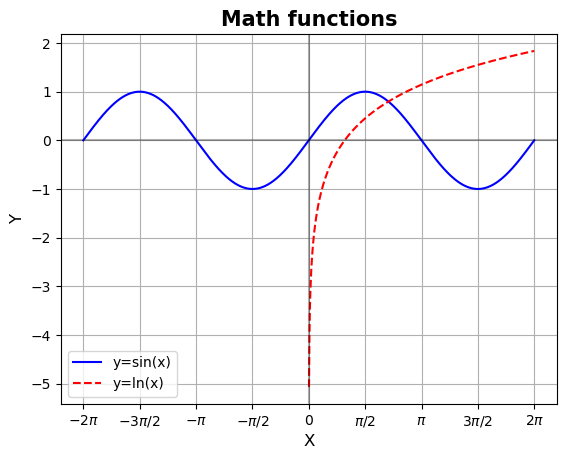

In [ ]:
# (◕‿◕)♡ your code here

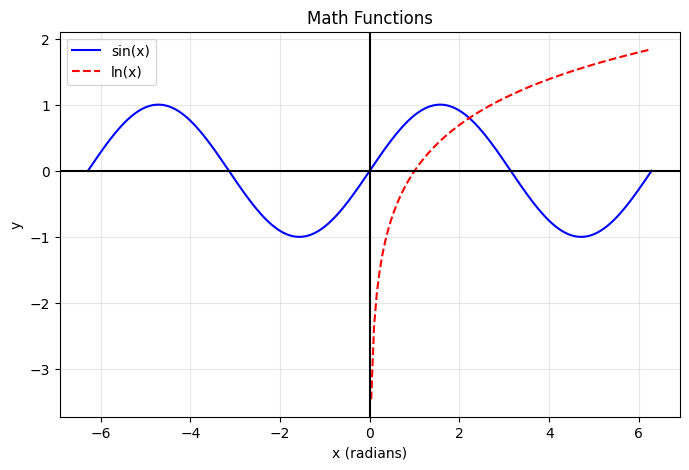

In [ ]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 200)
y1 = np.sin(x)
y2 = np.log(x)
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='sin(x)', color='blue', linestyle='-')
plt.plot(x, y2, label='ln(x)', color='red', linestyle='--')
plt.title('Math Functions')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Задание 6 (0.5 балла)

Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

Вам может пригодиться:
- plt.barh или ax.barh

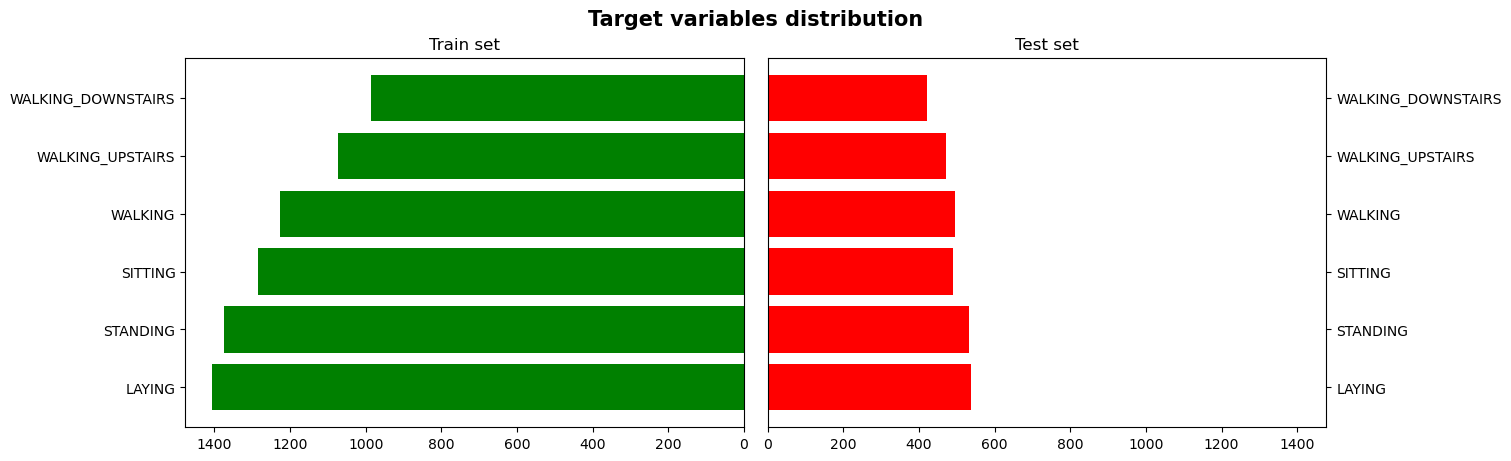

In [ ]:
# ̿' ̿'\̵͇̿̿\з=( ͡ °_̯͡° )=ε/̵͇̿̿/'̿'̿ ̿ your code here

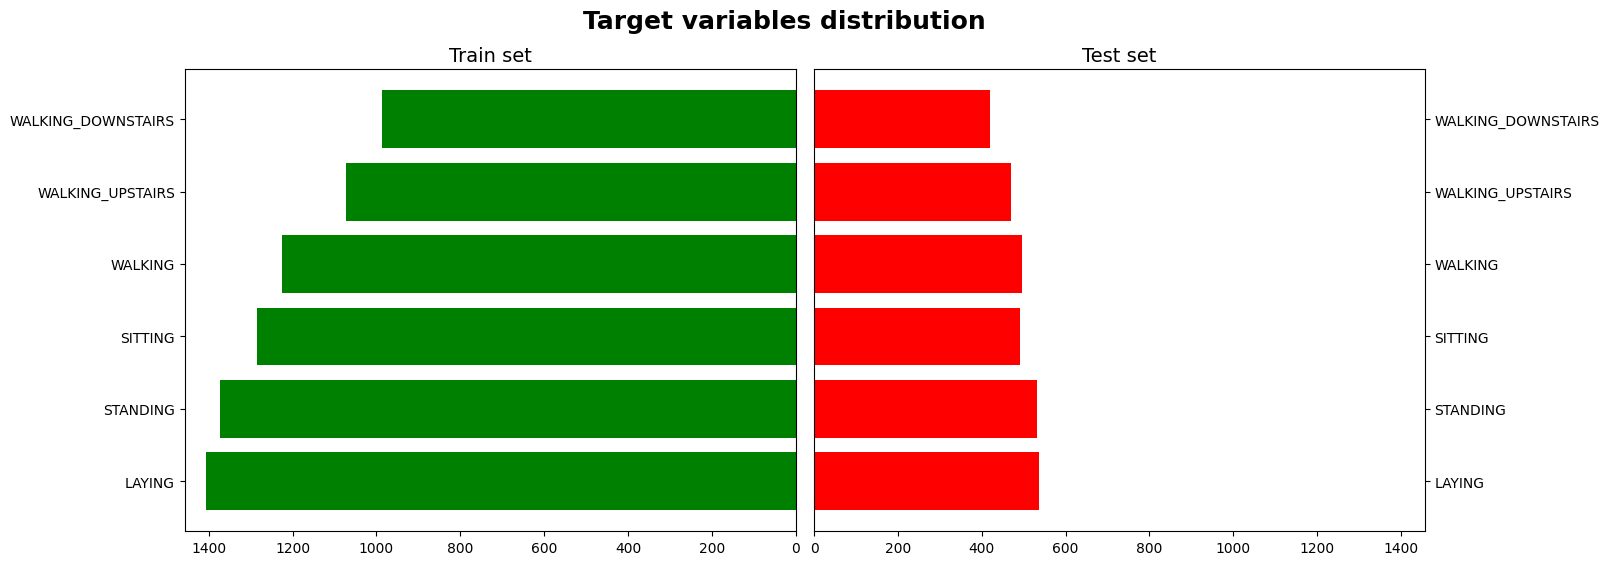

In [ ]:
train_counts = train['Activity'].value_counts()
category_order = train_counts.index
test_counts = test['Activity'].value_counts().reindex(category_order)
max_x = max(train_counts.max(), test_counts.max()) + 50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Target variables distribution', fontsize=18, fontweight='bold')
ax1.barh(category_order , train_counts, color='green')
ax1.set_title('Train set', fontsize=14)
ax1.set_xlim(max_x, 0)
ax2.barh(category_order , test_counts, color='red')
ax2.set_title('Test set', fontsize=14)
ax2.set_xlim(0, max_x)
ax2.yaxis.tick_right()
plt.subplots_adjust(wspace=0.03)
plt.show()

Правда на таких графиках проще проверять баланс классов таргета?)

### Задание 7 (0.5 балла)

Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными. Если будете брать код из семинарского ноутбука, то поменяйте в нем что-нибудь, например, цветовую гамму, иначе проверяющий будет карать :)

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

Вам может пригодиться:
- sns.heatmap
- методы get_text и set_text у атрибута texts графика

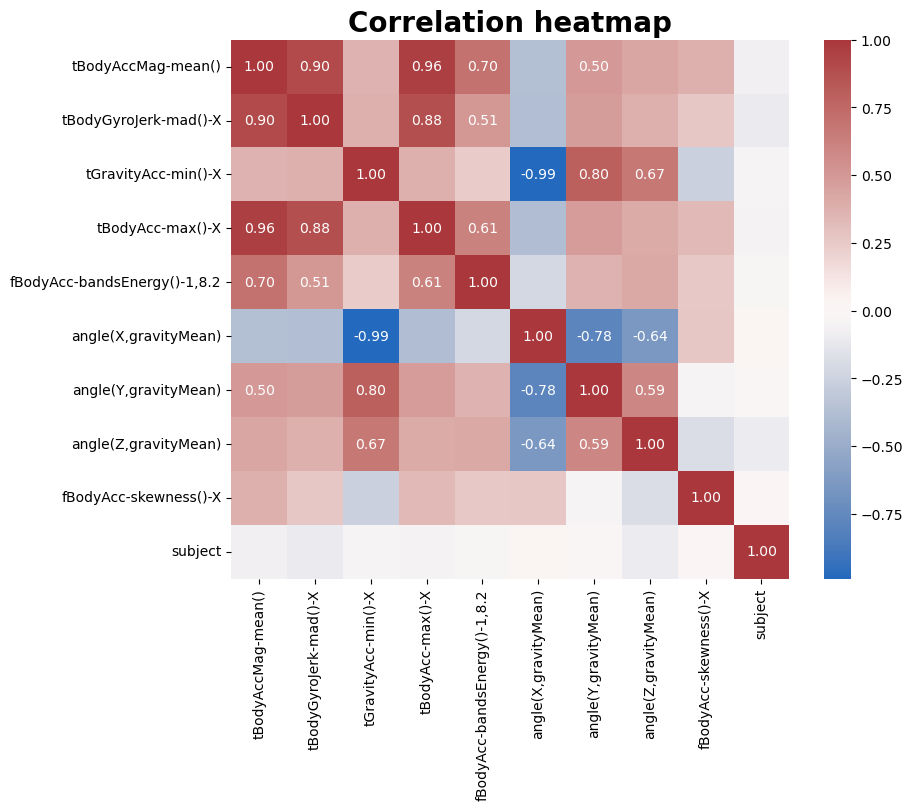

In [ ]:
# ღゝ◡╹)ノ♡ your code here

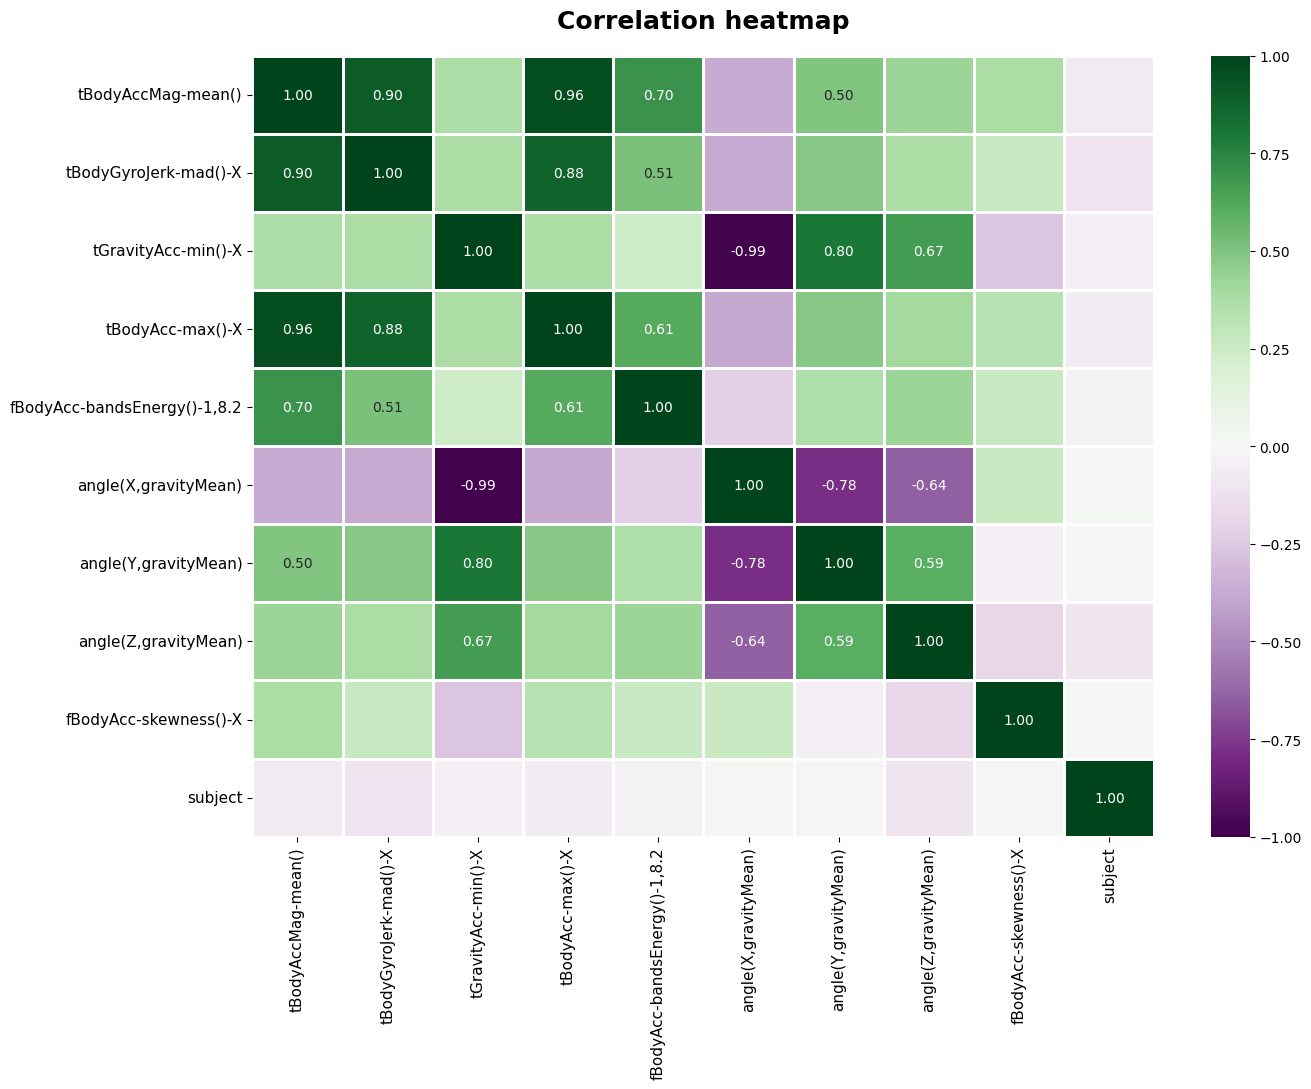

In [ ]:
plt.figure(figsize=(14, 11))
ax = sns.heatmap(train.corr(numeric_only=True),
                 annot=True,
                 fmt=".2f",
                 cmap="PRGn",
                 vmin=-1, vmax=1,
                 center=0,
                 linewidths=1,
                 linecolor='white')
for text in ax.texts:
    val_str = text.get_text()
    if val_str:
        val = float(val_str)
        if abs(val) < 0.5:
            text.set_text('')
plt.title('Correlation heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Признак, который стоит исключить из рассмотрения корреляций: 'subject'. Причина: 'subject' — это идентификатор испытуемого (номер человека), а не измеряемая физическая величина. Корреляция между номером человека и показателями датчиков не имеет физического смысла и может приводить к ложным выводам.



### Задание 8 (0.5 балла)

Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

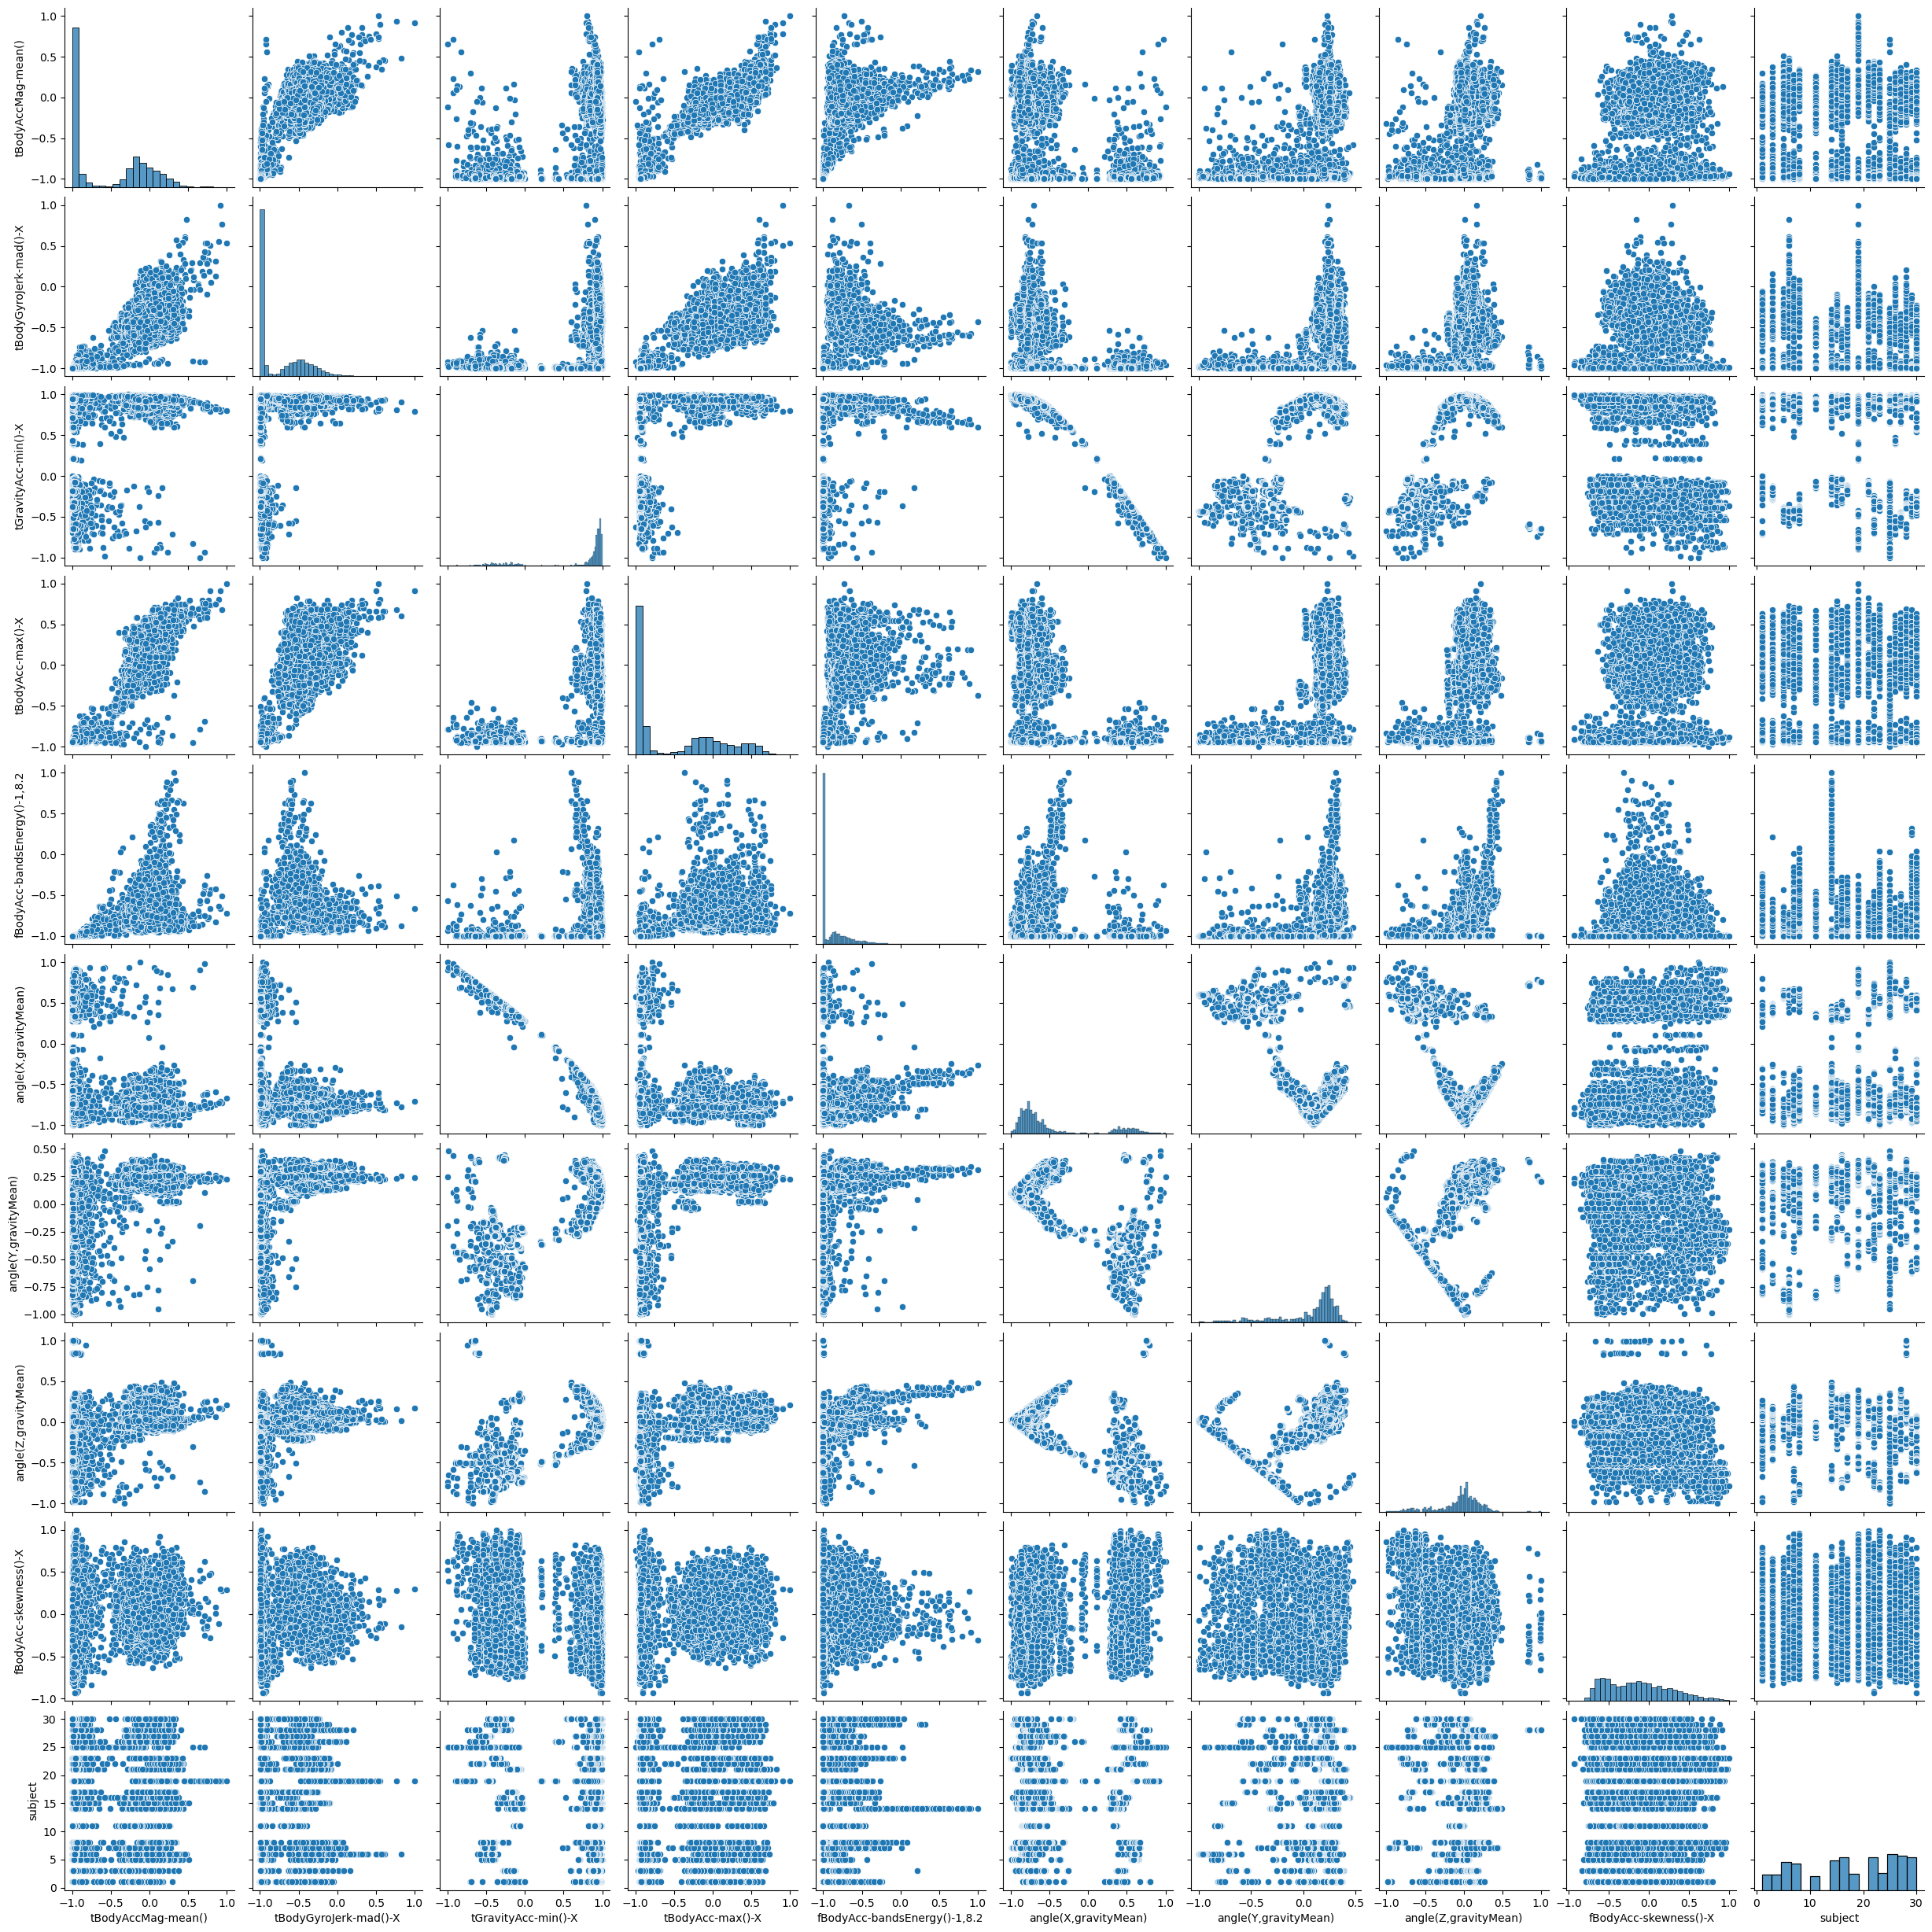

In [ ]:
# ♪ヽ( ⌒o⌒)人(⌒-⌒ )v ♪ your code here

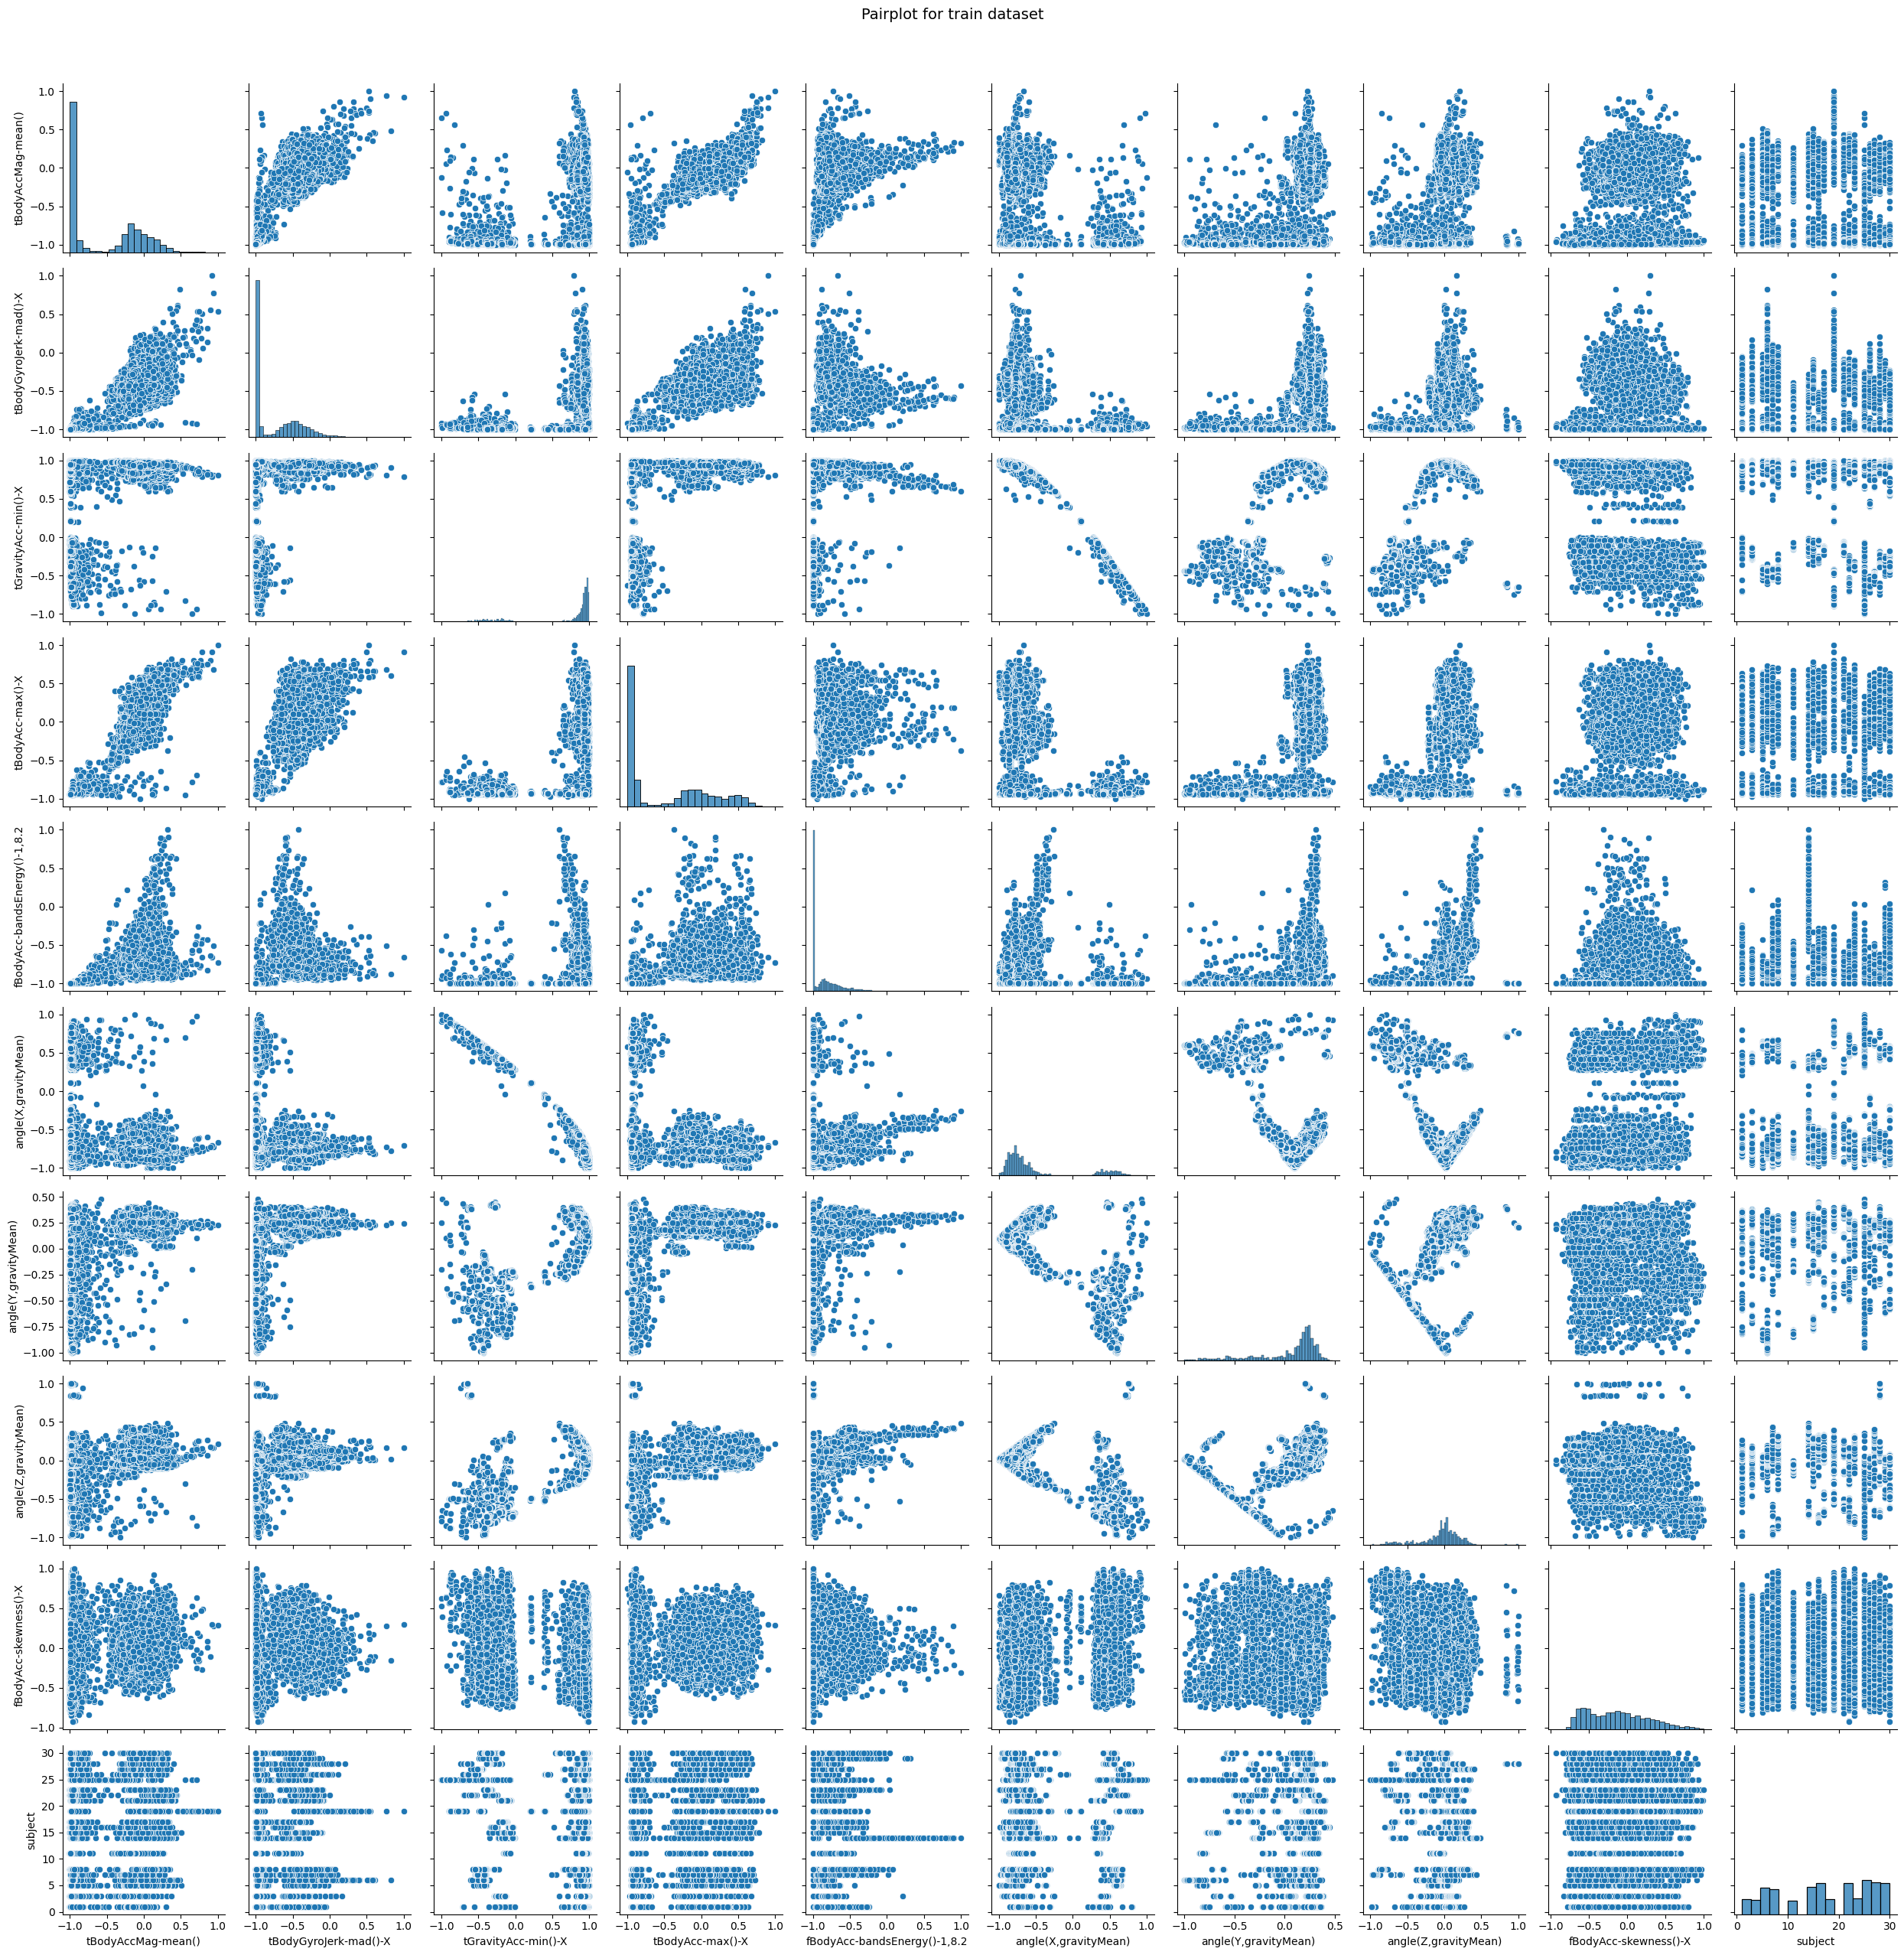

In [ ]:
sns.pairplot(train)
plt.suptitle('Pairplot for train dataset', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Потверждается, что subject не влияет на другие параметры, так как графики выглядят как ровные горизонтальные или вертикальные полосы. происходит это из-за того, что точки просто выстроились в ряд по ID испытуемых (от 1 до 30).
Также можно увидеть линейную зависимость некоторых величин, например: 1) tBodyAccMag-mean() и tBodyGyroJerk-mad()-X; 2) tGravityAcc-min()-X и angle(X,gravityMean); 3) tBodyGyroJerk-mad()-X и tBodyAcc-max()-X.

### Задание 9 (1 балл)

Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) `tBodyAccMag-mean()` для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

Вам может пригодиться:
- sns.kdeplot

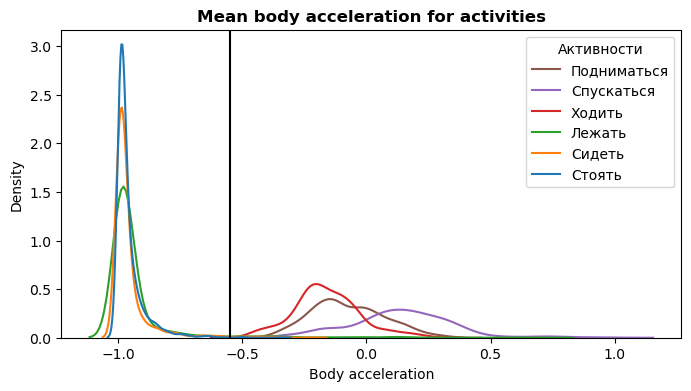

In [ ]:
# ʅ(◔౪◔ ) ʃ your code here

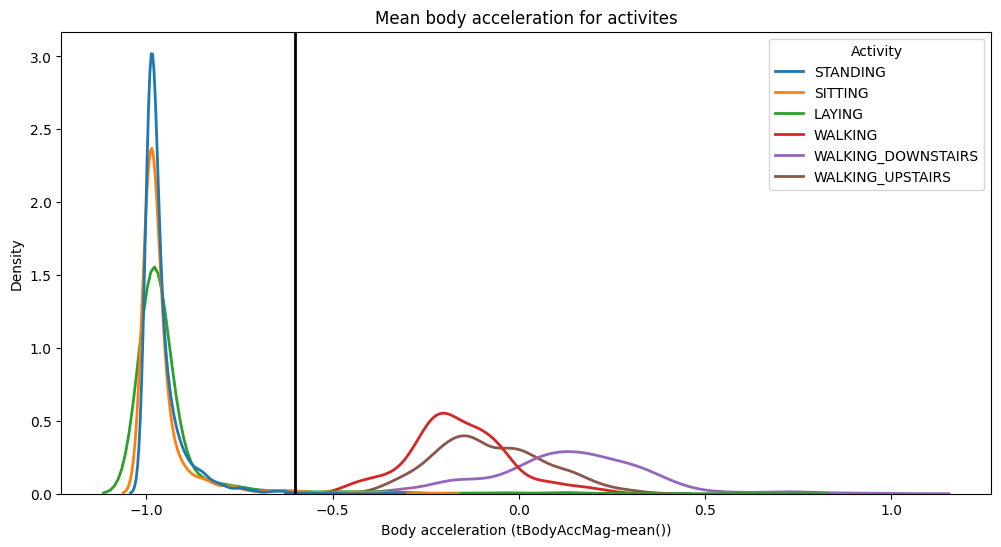

In [ ]:
activities = train['Activity'].unique()
train_plot = train.copy()
static_activities = ['LAYING', 'SITTING', 'STANDING']
dynamic_activities = ['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']

plt.figure(figsize=(12, 6))
sns.kdeplot(data=train_plot, x='tBodyAccMag-mean()', hue='Activity', common_norm=True, linewidth=2)

threshold = -0.6
plt.axvline(x=threshold, color='black', linestyle='-', linewidth=2)

plt.title('Mean body acceleration for activites')
plt.xlabel('Body acceleration (tBodyAccMag-mean())')
plt.ylabel('Density')
plt.show()

In [ ]:
def predict_group(value, threshold):
    if value < threshold:
        return 'static'
    else:
        return 'dynamic'
train_plot['group'] = train_plot['Activity'].apply(
    lambda x: 'static' if x in static_activities else 'dynamic'
)
train_plot['predicted_group'] = train_plot['tBodyAccMag-mean()'].apply(
    lambda x: predict_group(x, threshold)
)
accuracy = (train['group'] == train['predicted_group']).mean()
print(f"Доля правильных ответов (Accuracy): {accuracy:.2%}")

Доля правильных ответов (Accuracy): 98.95%


График плотности распределения демонстрирует следующую закономерность: все 6 видов активности почти четко распадаются на две непересекающиеся группы.
Вертикальная линия, проведенная на отметке X = -0.6, идеально разделяет эти группы. При расчете доля правильных ответов для такого простого правила (если X <= -0.6 то статика, иначе динамика) составила около 98.95%.
Данный результат возможен из-за физического смысла признака tBodyAccMag-mean(), который является по сути маркером наличия кинетической энергии (если есть, то динамика; если нет, то статика).

### Задание 10 (0.5 балла)

Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для `angle(X,gravityMean)` с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

Вам может пригодиться:
- sns.boxplot

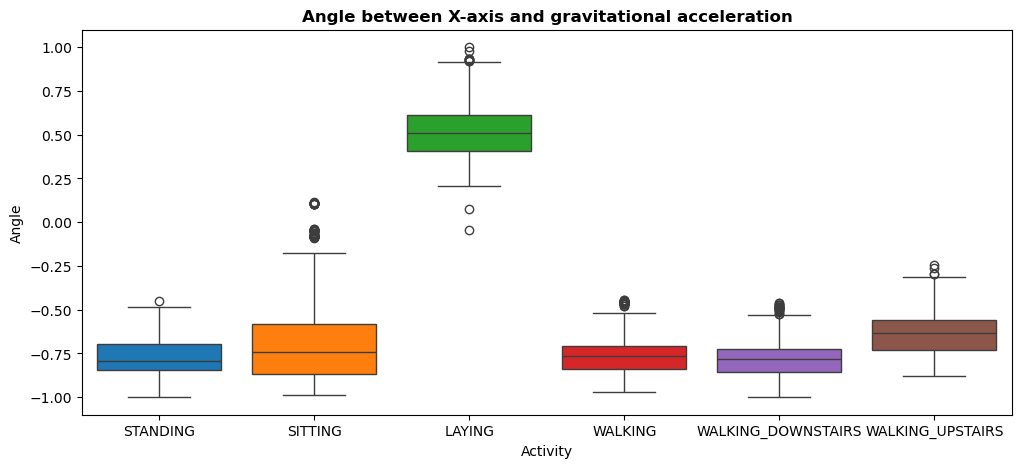

In [ ]:
# ^⨀ᴥ⨀^ your code here

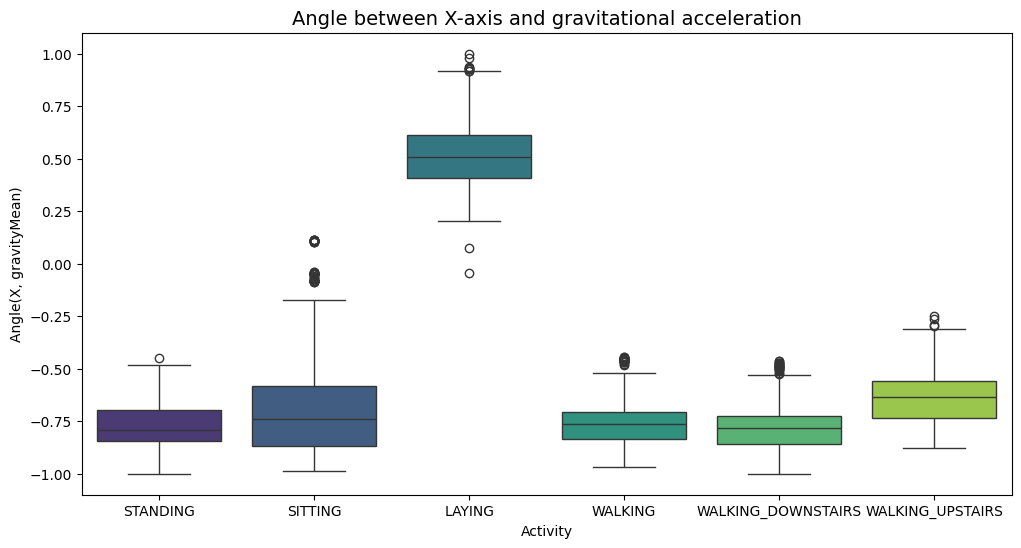

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='Activity', y='angle(X,gravityMean)', palette='viridis')
plt.title('Angle between X-axis and gravitational acceleration', fontsize=14)
plt.xlabel('Activity')
plt.ylabel('Angle(X, gravityMean)')
plt.show()

На графике отчетливо видно, что категория LAYING колоссально выделяется на фоне всех остальных активностей. Медиана и межквартильный размах ("прямоугольник") для класса LAYING находятся в положительной зоне (около 0.5), тогда как у всех остальных пяти классов значения отрицательные (от -0.5 до -1.0) и их "прямоугольники" даже близко не пересекаются с лежанием.
Причина в том, что используется признак angle(X,gravityMean), который отражает угол между осью X смартфона и вектором гравитационного ускорения Земли. В описании датасета указано, что смартфон был закреплен на поясе испытуемых, следовательно, во время вертикальных положений вектор гравитации направлен вниз, параллельно телу человека -> из-за этого угол по оси X для всех этих активностей примерно одинаков. Во время же горизонтального положения смартфон на поясе также поворачивается на 90 градусов -> вектор гравитации начинает действовать на телефон совершенно перпендикулярно торсу.

### Задание 11 (0.5 балла)

Посмотрим теперь на `tBodyAcc-max()-X`. Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

Вам может пригодиться:
- sns.violinplot

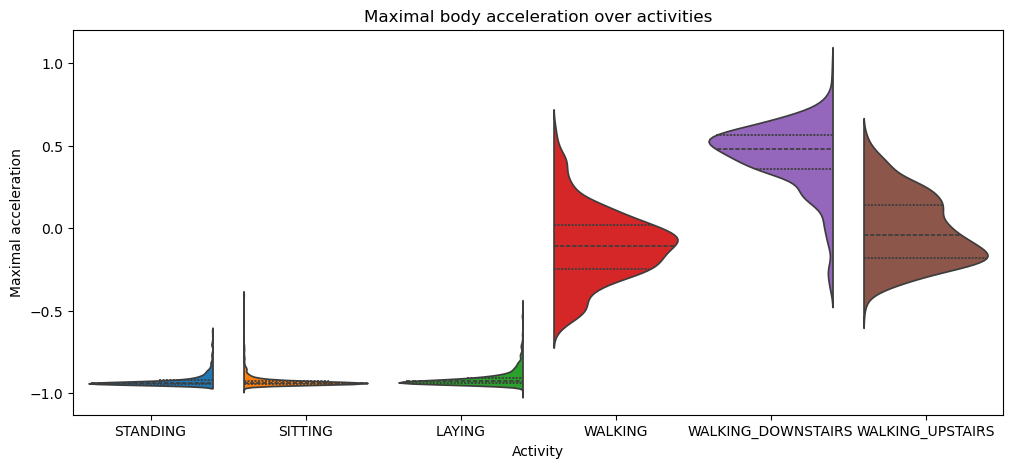

In [ ]:
# ( ͡☉ ͜ʖ ͡☉) your code here

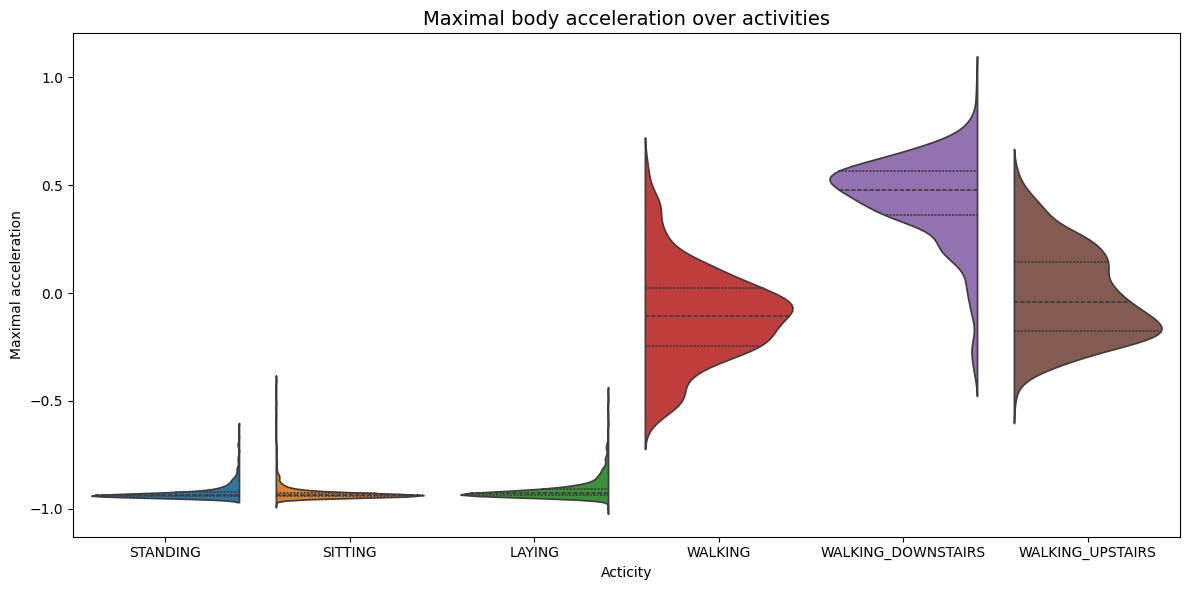

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='Activity', y='tBodyAcc-max()-X', hue='Activity',
               split=True, inner="quart")
plt.title('Maximal body acceleration over activities', fontsize=14)
plt.xlabel('Acticity')
plt.ylabel('Maximal acceleration')
plt.tight_layout()
plt.show()

По данному графику видно, что наибольшое значение для `tBodyAcc-max()-X` достигается у WALKING_DOWNSTAIRS. Причина в том, что максимальная величина ускорения тела по оси Х при движение вниз по лестнице.

### Задание 12 (1 балл)

Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения `fBodyAcc-bandsEnergy()-1,8.2` для динамичных активностей (`boxenplot` - немного измененый "ящик с усами") и `angle(Y,gravityMean)` для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec (заметили, что один график больше другого? попробуйте сами так сделать - вам понравится...)
- sns.boxenplot
- sns.histplot

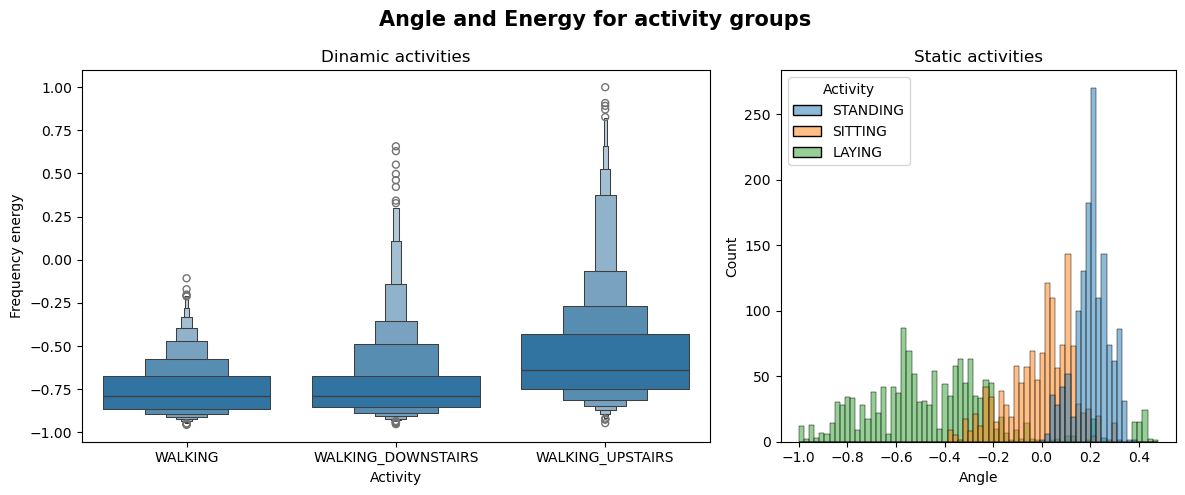

In [ ]:
# ‿( ́ ̵ _-`)‿ your code here

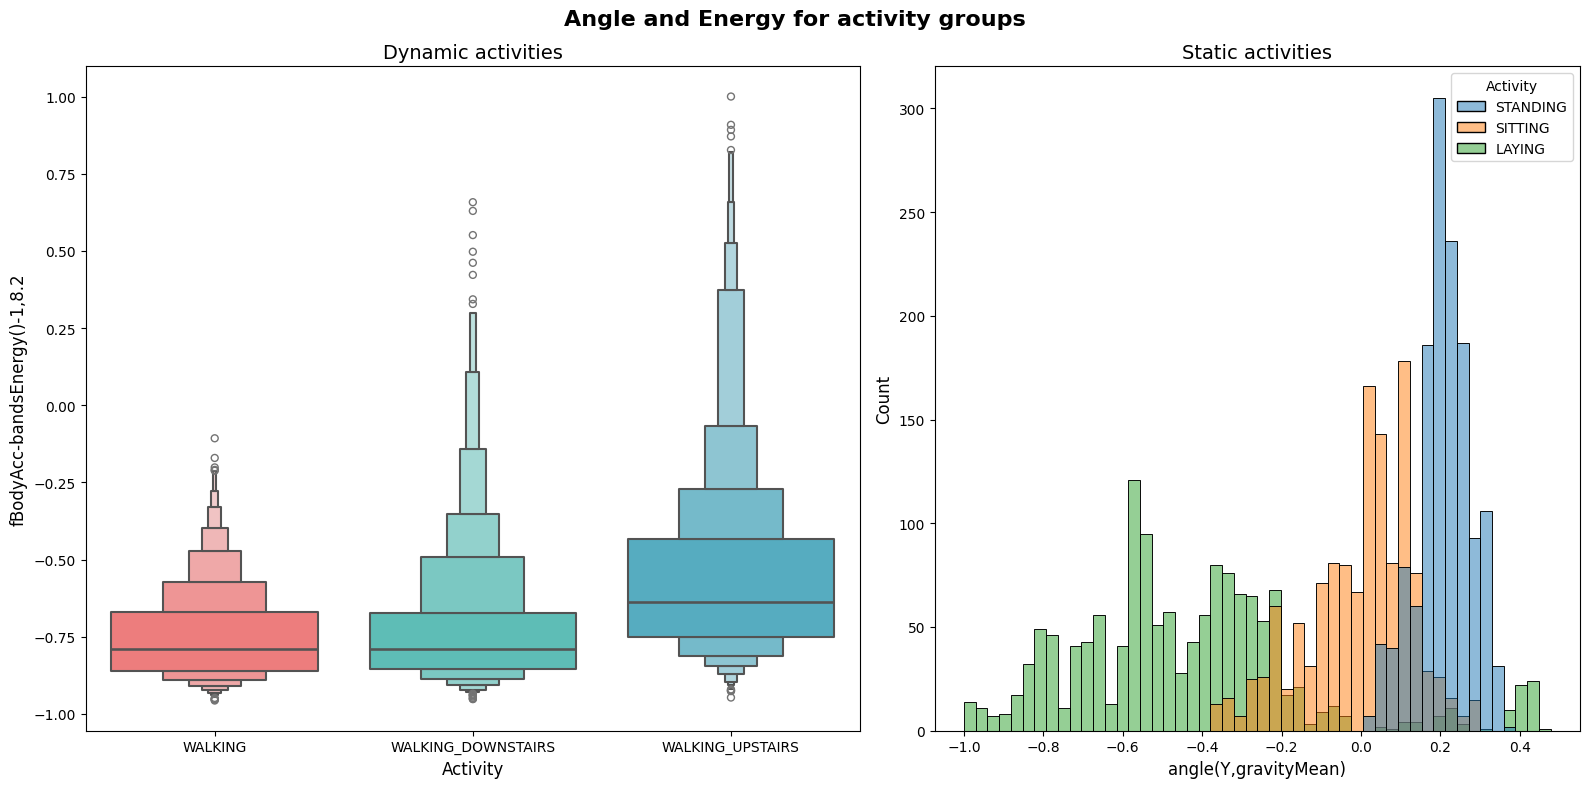

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, width_ratios=[1.2, 1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

dynamic_df = train_plot[train_plot['group'] == 'dynamic'].copy()
static_df = train_plot[train_plot['group'] == 'static'].copy()

boxen_plot = sns.boxenplot(data=dynamic_df, x='Activity', y='fBodyAcc-bandsEnergy()-1,8.2',
                           ax=ax1, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'], linewidth=1.5)

ax1.set_title('Dynamic activities', fontsize=14)
ax1.set_xlabel('Activity', fontsize=12)
ax1.set_ylabel('fBodyAcc-bandsEnergy()-1,8.2', fontsize=12)
ax1.tick_params(axis='x', labelsize=10)

sns.histplot(data=static_df, hue='Activity', x='angle(Y,gravityMean)', ax=ax2, bins=50, legend=True)
ax2.set_title('Static activities', fontsize=14)
ax2.set_xlabel('angle(Y,gravityMean)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)

plt.suptitle('Angle and Energy for activity groups',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Анализируя графики, можно заметить, что у WALKING_UPSTAIRS большее занчение fBodyAcc-bandsEnergy()-1,8.2; также заметим, что STANDING имеет большинство своих значений при angle(Y, gravityMean) > 0.15. При этом SITTING при -0.4 < angle(Y,gravityMean) < 0.3

### Задание 13 (0.5 балла)

Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения `fBodyAcc-skewness()-X` по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по `fBodyAcc-skewness()-X`? А если взять только те строки, где `fBodyAcc-skewness()-X < -0.376`, и теперь вывести боксплот распределения `angle(Y,gravityMean)` по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.boxplot

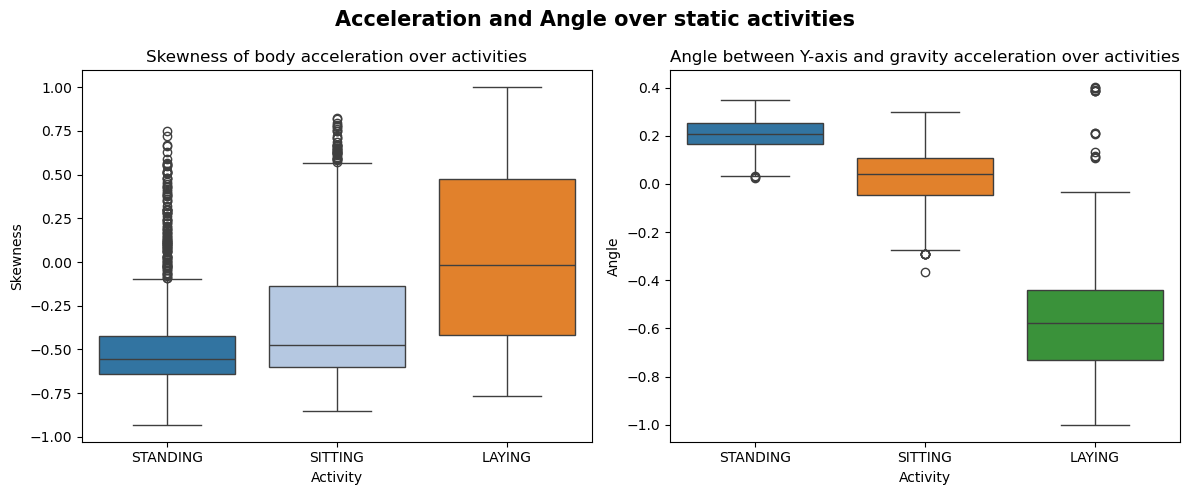

In [ ]:
# (ಠ_ಠ) your code here

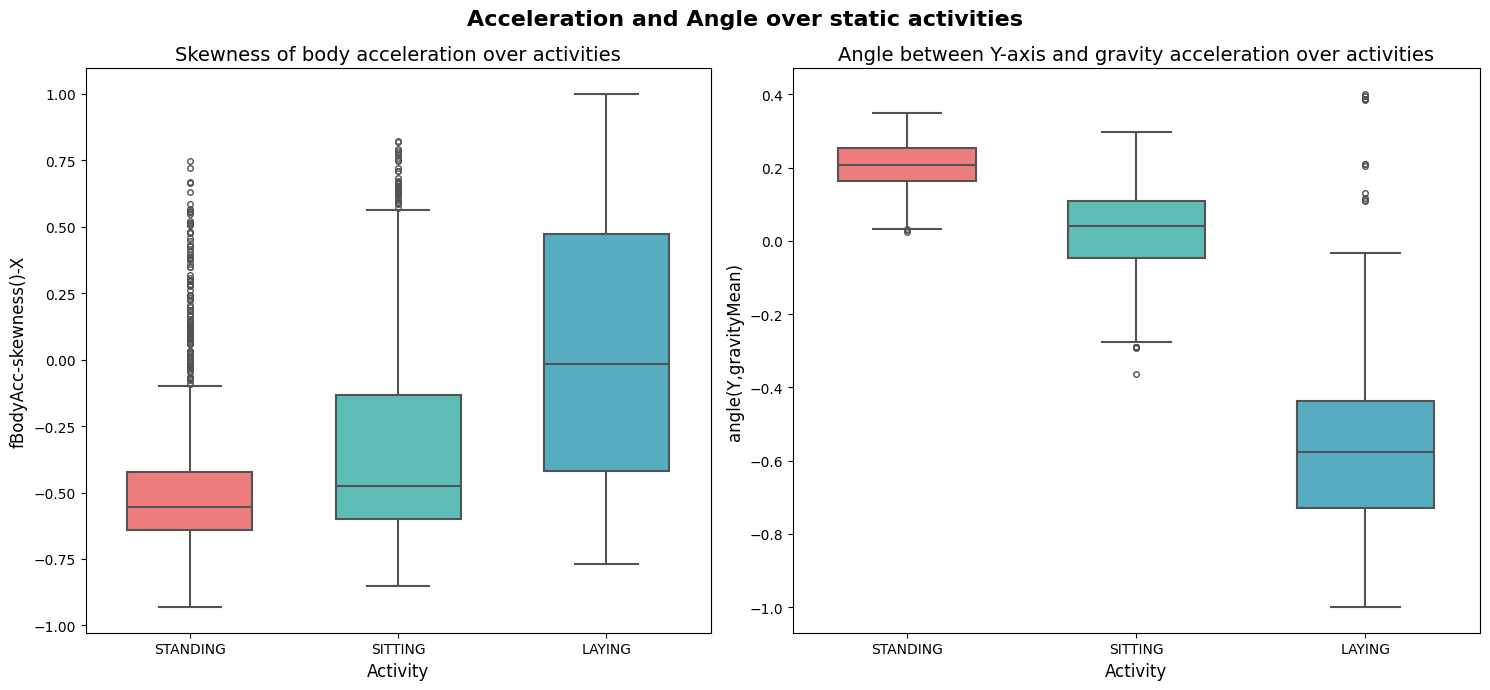

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 7))
gs = GridSpec(1, 2, width_ratios=[1, 1.1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

static_df = train_plot[train_plot['group'] == 'static'].copy()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

boxplot1 = sns.boxplot(data=static_df,
                       x='Activity',
                       y='fBodyAcc-skewness()-X',
                       ax=ax1,
                       palette=colors,
                       linewidth=1.5,
                       fliersize=4,
                       width=0.6)

ax1.set_title('Skewness of body acceleration over activities', fontsize=14)
ax1.set_xlabel('Activity', fontsize=12)
ax1.set_ylabel('fBodyAcc-skewness()-X', fontsize=12)

fil_df = static_df[static_df['fBodyAcc-skewness()-X'] < -0.376].copy()
boxplot2 = sns.boxplot(data=fil_df,
                        x='Activity',
                        y='angle(Y,gravityMean)',
                        ax=ax2,
                        palette=colors,
                        linewidth=1.5,
                        fliersize=4,
                        width=0.6)

ax2.set_title(f'Angle between Y-axis and gravity acceleration over activities', fontsize=14)
ax2.set_xlabel('Activity', fontsize=12)
ax2.set_ylabel('angle(Y,gravityMean)', fontsize=12)


plt.suptitle('Acceleration and Angle over static activities', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

1) При fBodyAcc-skewness()-X < -0.376 и angle(Y,gravityMean) > 0.1 -> STANDING
2) При fBodyAcc-skewness()-X < -0.376 и angle(Y,gravityMean) < -0.4 -> LAYING

Поздравляем, теперь вы на шажок ближе к тому, чтобы стать решающим деревом!

### Задание 14 (1 балл)

Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение `tBodyAcc-max()-X` на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог `tBodyAcc-max()-X < 0.157`. Для таких строк постройте диаграмму рассеяния для признака `tGravityAcc-min()-X`. Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где `tBodyAcc-max()-X < 0.157`, выбрать по некоторому порогу для `tGravityAcc-min()-X` строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 83%!

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.violinplot
- sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)

Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

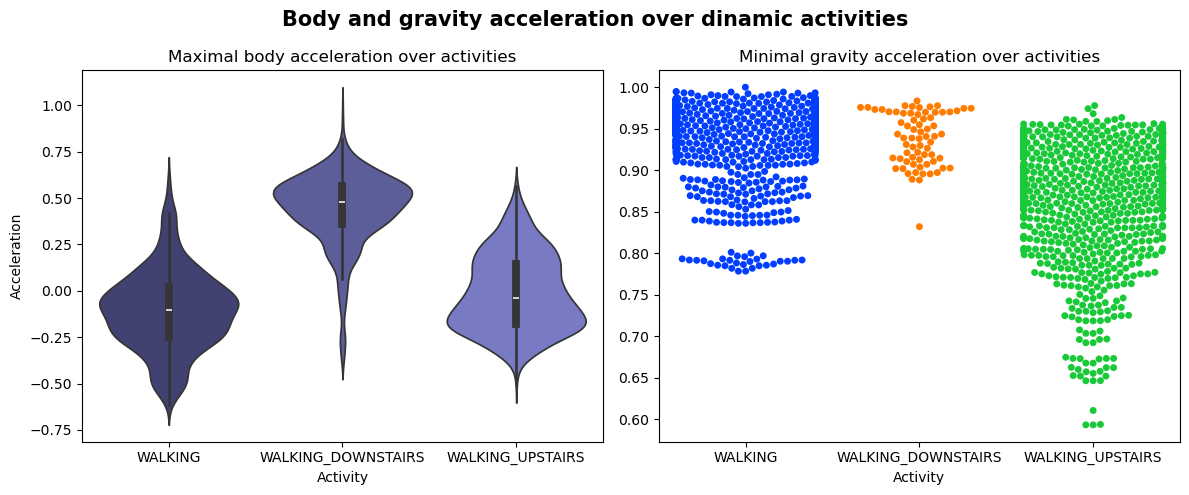

In [ ]:
# (✖╭╮✖) your code here

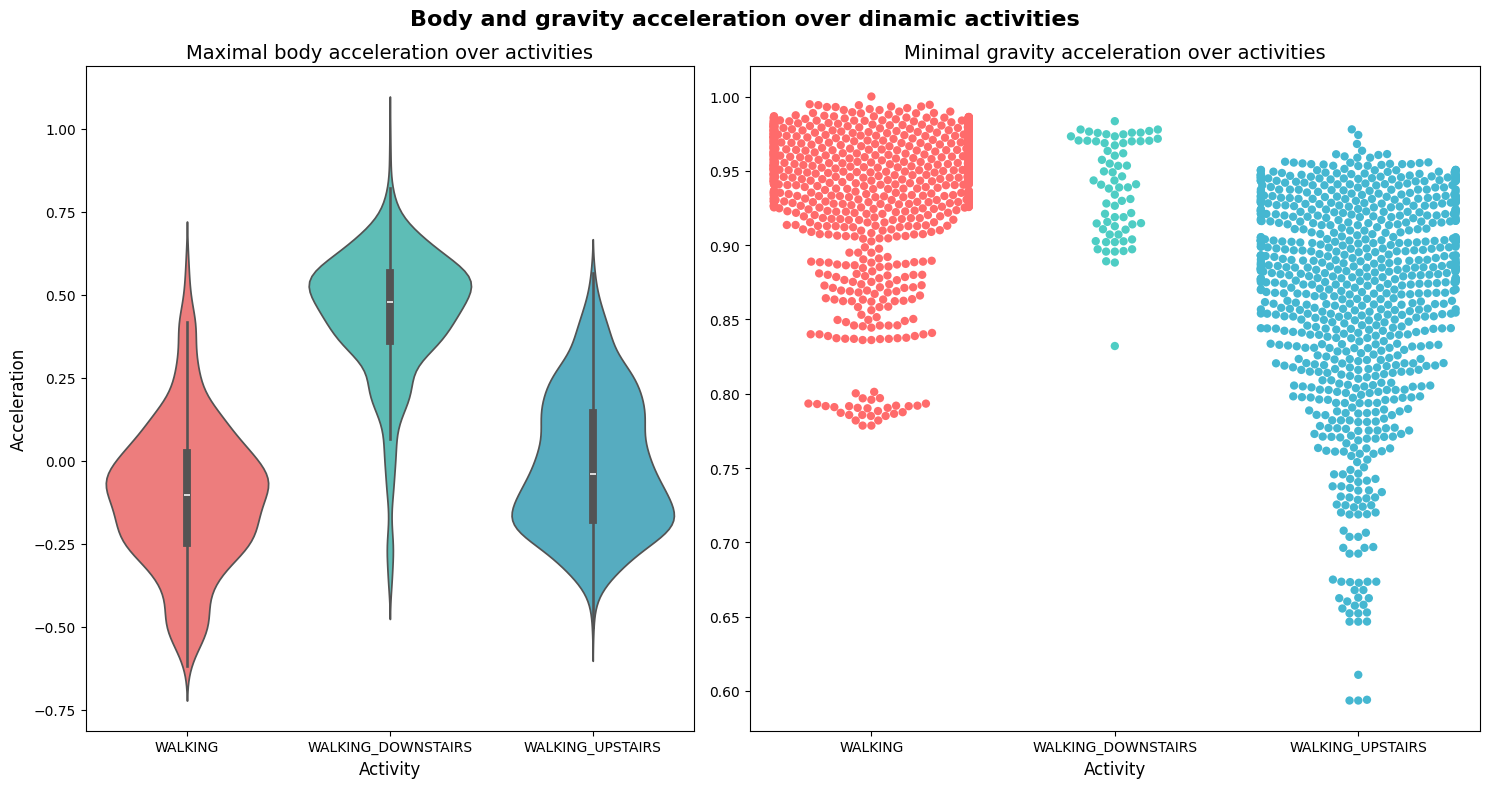

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1.2])

dynamic_df = train_plot[train_plot['group'] == 'dynamic'].copy()

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

violin_plot = sns.violinplot(data=dynamic_df,
                              x='Activity',
                              y='tBodyAcc-max()-X',
                              ax=ax1,
                              palette=colors)

ax1.set_title('Maximal body acceleration over activities', fontsize=14)
ax1.set_xlabel('Activity', fontsize=12)
ax1.set_ylabel('Acceleration', fontsize=12)

fil_df = dynamic_df[dynamic_df['tBodyAcc-max()-X'] < 0.157].copy()
sns.swarmplot(data=fil_df, x='Activity', y='tGravityAcc-min()-X',
              hue='Activity', ax=ax2, palette=colors, size=6)

ax2.set_title('Minimal gravity acceleration over activities', fontsize=14)
ax2.set_xlabel('Activity', fontsize=12)
ax2.set_ylabel('')

plt.suptitle('Body and gravity acceleration over dinamic activities', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

 При tBodyAcc-max()-X > 0.22 -> WALKING_DOWNSTAIRS

### Задание 15 (0.5 балла)

Теперь попробуем более интерактивные графики. Установите библиотеку `plotly` (обычно `pip install plotly` или `conda install plotly`). Синтаксис очень похож на `seaborn`, но вот [документация для plotly.express](https://plotly.com/python-api-reference/plotly.express.html).

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать.

In [ ]:
%%time
from sklearn.manifold import TSNE
tsne = TSNE(random_state=666, n_components=2)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne = TSNE(random_state=666, n_components=3)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

CPU times: user 5min 53s, sys: 291 ms, total: 5min 53s
Wall time: 6min 1s


Теперь нарисуйте scatter-график через `plotly.express` для `df_2_comp` с выделением цветами активностей. Красиво получилось? Видны скопления точек одного цвета? Можно разные активности отделить линиями на данном графике?

In [ ]:
# ʅ(◔౪◔ ) ʃ your code here
import plotly.express as px

fig_2d = px.scatter(
    df_2_comp,
    x='x',
    y='y',
    color='Activity',
    title='2D graph',
    labels={'color': 'Activity'},
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_name='Activity'
)

fig_2d.update_layout(
    width=900,
    height=700,
    title_font_size=18,
    legend_title_font_size=14
)

fig_2d.show()

Рассматривая график в 2D видно, что можно поделить данные на статичесткие и динамические активности одной линией (а точнее вертикальной), более того, сожно заметить, что LAYING полностью отделяется от остальных, остальные тоже можно отделять, но это уже будет иметь большую погрешность при расчёте accuracy например.

Мы не отстаем от трендов и тоже можем в 3D. Сейчас и вы научитесь (если еще не умеете). Нарисуйте scatter_3d-график через `plotly.express` для `df_3_comp` с выделением цветами активностей. Повращайте его. Нормально получилось? Есть ли какая-то структура у точек?

In [ ]:
# (✧≖‿ゝ≖) your code here
fig_3d = px.scatter_3d(
    df_3_comp,
    x='x',
    y='y',
    z='z',
    color='Activity',
    title='3D graph',
    labels={'color': 'Activity'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    hover_name='Activity'
)

fig_3d.update_layout(
    width=1000,
    height=800,
    title_font_size=18,
    legend_title_font_size=14
)

fig_3d.show()

По сути это 3D представление предыдущего 2D графика, поэтому закномерности работают те же.

### Задание 16 (1 балл)

Мы сделали вам fit. Ваша очередь сделать predict. Допишите функцию, которая принимает на вход датафрейм с признаками, а выдает вектор из предсказаний - для каждой строки датафрейма вы определяете, к какому классу принадлежит объект. Рекомендуем сразу записывать из строками, а не кодировать в числа. Дальше фукнция `accuracy_score` выдаст вам долю правильных ответов.

Подсказка: вы уже отделили категории друг от друга по каким-то признакам. Воспользуйтесь этим знанием! Используя только проведенный вами анализ можно спокойно выбить не менее 75% на train и test! Если вы получите меньше 75%, то балл будет снижен. Авторское решение (на основе всех графиков выше) выбивает 81% и 77% на train и test соответственно. [Шпаргалка с готовыми идеями для такой задачи](https://rutube.ru/video/c6cc4d620b1d4338901770a44b3e82f4/)

In [87]:
def predict(df: pd.DataFrame):
    # ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ your code here
    results = []
    for i, r in df.iterrows():
        if r['tBodyAccMag-mean()'] < -0.6:
            if r['angle(X,gravityMean)'] > 0.2:
                results.append('LAYING')
            elif r['angle(Y,gravityMean)'] >= 0.15:
                results.append('STANDING')
            elif -0.4 < r['angle(Y,gravityMean)'] and r['angle(Y,gravityMean)'] < 0.3:
                results.append('SITTING')

        else:
            if r['tBodyAcc-max()-X'] >= 0.22:
                results.append('WALKING_DOWNSTAIRS')
            elif (r['fBodyAcc-bandsEnergy()-1,8.2'] > -0.5 or
                  (r['tBodyAcc-max()-X'] < 0.157 and r['tGravityAcc-min()-X'] < 0.95)):
                results.append('WALKING_UPSTAIRS')
            else:
                results.append('WALKING')

    return results

def accuracy_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    return (y_true == y_pred).mean()

In [88]:
train_preds = predict(train)
test_preds = predict(test)
print(f"Accuracy on train set => {accuracy_score(train['Activity'], train_preds)}")
print(f"Accuracy on test set => {accuracy_score(test['Activity'], test_preds)}")

Accuracy on train set => 0.8235854189336235
Accuracy on test set => 0.7743467933491687


__Место для мема и/или фидбэка__

> Фидбэк: мне безумно нравится данный курс. Очень интересно погружаться в ML (в начале не думала, что так затянет), поэтому даже не жалко много часов тратить на ДЗ <3.
Уже нетерпится получить ДЗ по kNN или lineal regression)))



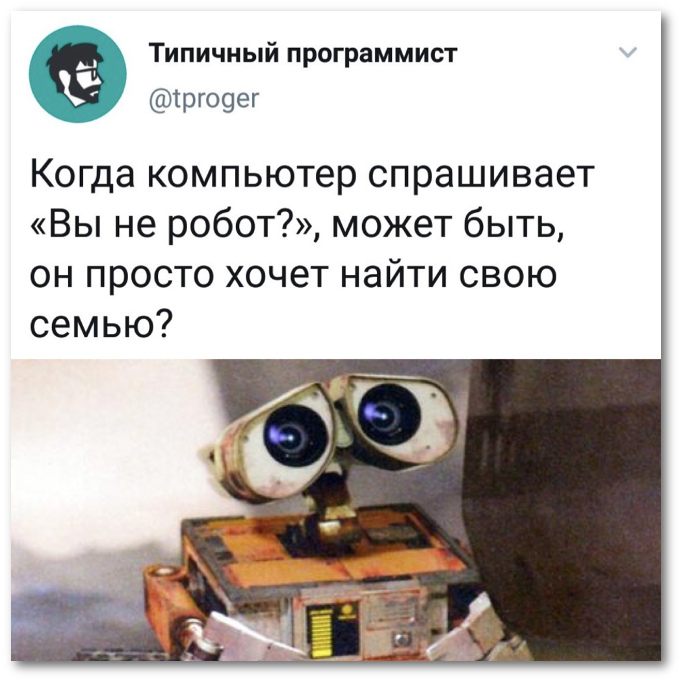